# T1 · Đo thử PerceptionHealthNet trên 24 ảnh DRIVE-C (checkpoint của tác giả, không huấn luyện)

Notebook này chạy mô hình **PerceptionHealthNet** bằng checkpoint tác giả đã train sẵn (`epoch_021_best.pth`, có trong repo) trên **24 clip** của DRIVE-C, lấy **một frame (frame 54)** mỗi clip, và cho ra bảng `gshi_pred`.

**24 clip gồm:**

| Nhóm | Clip | Số ảnh |
|---|---|---|
| Ngày (S01) | sạch + motion_blur s1–s5 + underexposure s1–s5 | 11 |
| Đêm (S06) | sạch + motion_blur s1–s5 + underexposure s1–s5 | 11 |
| Đêm sạch, ca khó của baseline | S07 sạch, S08 sạch | 2 |

**Không tải zip 9,1 GB.** Notebook chỉ lấy đúng 24 file (khoảng 170 MB) từ Zenodo bằng HTTP Range.

**Trước khi bấm Run All, trên Kaggle:**
1. Panel bên phải → **Session options** → **Internet: On** (cần xác minh số điện thoại trong tài khoản Kaggle).
2. **Accelerator**: chọn **GPU T4** (nhanh hơn) hoặc **None** (CPU vẫn chạy được). Tránh **P100**: bản PyTorch mới trên Kaggle có thể không hỗ trợ GPU này.

**Quy ước nhãn khi viết báo cáo:** số trong cột `gshi_pred_author` là **[NGUỒN]**; số do notebook này tính là **[NHÓM ĐO]**.

## Bước 1 · Cấu hình

Các hằng số dùng cho cả notebook. Không cần sửa gì nếu muốn chạy đúng bộ 24 ảnh đề xuất.

- `REPO_TAG = "v1.0.1"`: bản phát hành của repo (commit `caf1665…`), bản `main` hiện tại.
- `FRAME_IDX = 54`: frame được lấy làm "ảnh". Đây là một trong 8 frame mà tác giả dùng (`0, 18, 36, 54, 73, 91, 109, 127`).
- Các clip hỏng khớp từng pixel với clip sạch, nên cùng frame 54 ở mọi clip trong một cảnh thì chỉ khác nhau ở mức lỗi.

In [1]:
import os, sys, re, json, hashlib, subprocess, time
from pathlib import Path

REPO_URL   = "https://github.com/shiv-aher/drive-c-dataset.git"
REPO_TAG   = "v1.0.1"
ZENODO_ZIP = "https://zenodo.org/records/19656444/files/drivec_core_v1.zip?download=1"
CKPT_SHA256 = "c210d9a4f207584687583d1ab5b96a99e12b2f3dbb2727464c6c039e44fb8c0b"  # theo docs/baseline_model.md của repo

FRAME_IDX  = 54          # frame dùng làm "ảnh"
NUM_FRAMES = 8           # tác giả lấy 8 frame đều nhau mỗi clip
H, W       = 384, 1280   # kích thước đầu vào của mô hình

WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./kaggle_work")
WORK.mkdir(parents=True, exist_ok=True)
REPO = WORK / "drive-c-dataset"
DATA = WORK / "data"
print("Thư mục làm việc:", WORK.resolve())

Thư mục làm việc: /kaggle/working


## Bước 2 · Cài thư viện và lấy code + checkpoint của tác giả

- Cài `remotezip` (đọc từng file bên trong zip từ xa, không tải cả zip).
- `git clone` repo ở tag `v1.0.1`. Checkpoint 94 MB nằm sẵn trong repo.
- Kiểm tra SHA-256 của checkpoint trùng với giá trị tác giả ghi trong `docs/baseline_model.md`. Nếu không trùng thì dừng lại: đang dùng sai file.

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "remotezip"], check=True)

if not REPO.exists():
    subprocess.run(["git", "clone", "--quiet", "--depth", "1", "--branch", REPO_TAG, REPO_URL, str(REPO)], check=True)
commit = subprocess.run(["git", "-C", str(REPO), "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print("Repo tag", REPO_TAG, "-> commit", commit)

ckpt_path = REPO / "checkpoints" / "epoch_021_best.pth"
sha = hashlib.sha256(ckpt_path.read_bytes()).hexdigest()
print("Checkpoint:", ckpt_path.name, f"{ckpt_path.stat().st_size/1e6:.1f} MB")
print("SHA-256   :", sha)
assert sha == CKPT_SHA256, "Checkpoint KHÔNG trùng SHA-256 tác giả công bố. Dừng lại."
print("OK: checkpoint đúng bản tác giả công bố.")

Note: switching to 'caf16657b87cec8518008b74c72dd0dcb6088eb6'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false



Repo tag v1.0.1 -> commit caf16657b87cec8518008b74c72dd0dcb6088eb6
Checkpoint: epoch_021_best.pth 94.3 MB
SHA-256   : c210d9a4f207584687583d1ab5b96a99e12b2f3dbb2727464c6c039e44fb8c0b
OK: checkpoint đúng bản tác giả công bố.


## Bước 3 · Liệt kê 24 clip cần dùng

Mỗi clip có `sample_id` theo quy ước của dataset, ví dụ `S06_motion_blur_s3`. Cell này chỉ dựng danh sách và kiểm tra đủ 24, chưa tải gì.

In [3]:
SEVS = ["s1", "s2", "s3", "s4", "s5"]
CORRS = ["motion_blur", "underexposure"]

clips = []
for sid in ["S01", "S06"]:
    clips.append(dict(sample_id=f"{sid}_clean", scenario=sid, corruption="clean", sev_name="s0"))
    for c in CORRS:
        for s in SEVS:
            clips.append(dict(sample_id=f"{sid}_{c}_{s}", scenario=sid, corruption=c, sev_name=s))
for sid in ["S07", "S08"]:
    clips.append(dict(sample_id=f"{sid}_clean", scenario=sid, corruption="clean", sev_name="s0"))

assert len(clips) == 24, len(clips)
print(len(clips), "clip:")
print([c["sample_id"] for c in clips])

24 clip:
['S01_clean', 'S01_motion_blur_s1', 'S01_motion_blur_s2', 'S01_motion_blur_s3', 'S01_motion_blur_s4', 'S01_motion_blur_s5', 'S01_underexposure_s1', 'S01_underexposure_s2', 'S01_underexposure_s3', 'S01_underexposure_s4', 'S01_underexposure_s5', 'S06_clean', 'S06_motion_blur_s1', 'S06_motion_blur_s2', 'S06_motion_blur_s3', 'S06_motion_blur_s4', 'S06_motion_blur_s5', 'S06_underexposure_s1', 'S06_underexposure_s2', 'S06_underexposure_s3', 'S06_underexposure_s4', 'S06_underexposure_s5', 'S07_clean', 'S08_clean']


## Bước 4 · Tải đúng 24 clip từ Zenodo (không tải zip 9,1 GB)

Zenodo hỗ trợ HTTP Range, nên `remotezip` đọc mục lục zip trước rồi chỉ kéo các file cần.

Điều cần biết về tên file trong zip thật:
- Thư mục gốc là `drivec_core_v1/` (không phải `drive-c-core-v1/` như README ghi).
- Clip sạch tên dạng `S01_video_018_clean.mp4`, **không** phải `S01_clean.mp4`. Vì vậy cell này tìm clip sạch bằng mẫu `S01_*clean.mp4`.
- Clip hỏng nằm ở `corrupted/<loại lỗi>/<sN>/<sample_id>.mp4`.

`zipfile` tự kiểm tra CRC-32 khi giải nén, nên file hỏng sẽ báo lỗi. SHA-256 từng file được ghi vào `fetch_sha256.txt` để làm bằng chứng.

In [4]:
from remotezip import RemoteZip

def resolve_name(c, names):
    sid, corr, sev = c["scenario"], c["corruption"], c["sev_name"]
    if corr == "clean":
        pat = re.compile(rf"^[^/]+/clean_clips/{sid}_.*clean\.mp4$")
        hits = [n for n in names if pat.match(n)]
        assert len(hits) == 1, (sid, hits)
        return hits[0]
    pat = re.compile(rf"^[^/]+/corrupted/{corr}/{sev}/{c['sample_id']}\.mp4$")
    hits = [n for n in names if pat.match(n)]
    assert len(hits) == 1, (c["sample_id"], hits)
    return hits[0]

DATA.mkdir(parents=True, exist_ok=True)
t0 = time.time()
total = 0
try:
    with RemoteZip(ZENODO_ZIP) as z:
        names = [i.filename for i in z.infolist()]
        sizes = {i.filename: i.compress_size for i in z.infolist()}
        print("Mục lục zip:", len(names), "mục")
        for c in clips:
            n = resolve_name(c, names)
            c["zip_name"] = n
            c["path"] = DATA / n
            if not c["path"].exists():
                z.extract(n, DATA)
            total += sizes[n]
except Exception as e:
    raise RuntimeError(
        "Không tải được từ Zenodo. Kiểm tra: (1) Internet đã bật trong Session options chưa; "
        "(2) thử chạy lại cell; (3) nếu vẫn lỗi, xem mục 'Nếu Zenodo không truy cập được' trong hướng dẫn."
    ) from e

print(f"Đã có {len(clips)} clip, {total/1e6:.0f} MB, mất {time.time()-t0:.0f} giây")
with open(WORK / "fetch_sha256.txt", "w") as f:
    for c in clips:
        f.write(hashlib.sha256(c["path"].read_bytes()).hexdigest() + "  " + c["zip_name"] + "\n")
print("Đã ghi", WORK / "fetch_sha256.txt")

Mục lục zip: 693 mục
Đã có 24 clip, 170 MB, mất 157 giây
Đã ghi /kaggle/working/fetch_sha256.txt


## Bước 5 · Đọc metadata của tác giả

Lấy từ `final_metadata.csv` trong repo, ghép theo `sample_id`:
- `gshi_gt`: nhãn tham chiếu, tính bằng công thức từ severity (không phải phép đo).
- `gshi_pred`: kết quả của tác giả (**[NGUỒN]**), dùng để kiểm tra lại pipeline ở Bước 8.
- `extra_json`: tham số thật của lỗi (`ksize` cho motion_blur, `delta_ev` cho underexposure).

In [5]:
import pandas as pd, numpy as np

meta = pd.read_csv(REPO / "dataset" / "final_metadata.csv").set_index("sample_id")
assert len(meta) == 610

for c in clips:
    row = meta.loc[c["sample_id"]]
    c["time_of_day"]   = row["time_of_day"]
    c["split"]         = row["split"]
    c["severity_value"] = float(row["severity_value"])
    c["gshi_gt"]       = float(row["gshi_gt"])
    c["gshi_pred_author"] = float(row["gshi_pred"])
    extra = json.loads(row["extra_json"]) if isinstance(row["extra_json"], str) else {}
    if c["corruption"] == "motion_blur":
        c["param"] = f"ksize={extra['ksize']}px"
    elif c["corruption"] == "underexposure":
        c["param"] = f"delta_ev={extra['delta_ev']}"
    else:
        c["param"] = "-"

pd.DataFrame(clips)[["sample_id", "time_of_day", "severity_value", "param", "gshi_gt", "gshi_pred_author"]]

,sample_id,time_of_day,severity_value,param,gshi_gt,gshi_pred_author
0,S01_clean,day,0.00,-,1.000000,0.221905
1,S01_motion_blur_s1,day,0.08,ksize=11px,0.896599,0.318455
2,S01_motion_blur_s2,day,0.18,ksize=13px,0.771227,0.357302
3,S01_motion_blur_s3,day,0.35,ksize=19px,0.568989,0.221091
4,S01_motion_blur_s4,day,0.55,ksize=27px,0.351605,0.114303
5,S01_motion_blur_s5,day,0.75,ksize=33px,0.162893,0.059963
6,S01_underexposure_s1,day,0.08,delta_ev=-0.16,0.934886,0.219617
7,S01_underexposure_s2,day,0.18,delta_ev=-0.36,0.851932,0.205273
8,S01_underexposure_s3,day,0.35,delta_ev=-0.7,0.706200,0.116198
9,S01_underexposure_s4,day,0.55,delta_ev=-1.1,0.524770,0.030984


## Bước 6 · Nạp mô hình bằng checkpoint của tác giả (không huấn luyện)

Dùng lại **nguyên hàm của tác giả** (`load_model`, `preprocess_frame`, `read_sampled_frames` trong `scripts/add_gshi_pred.py`) để tránh lệch tiền xử lý.

Hai điều cần biết:
- Mô hình khởi tạo với `pretrained_backbone=False` (không tải trọng số ImageNet). Toàn bộ trọng số đến từ checkpoint, nạp với `strict=True`.
- Pixel head của mô hình được tạo "lười" ở lần forward đầu, nên `load_model` chạy một lần forward với tensor 0 trước khi nạp trọng số. Hàm của tác giả đã xử lý việc này.

Thứ tự 12 lớp lấy từ `configs/taxonomy/camera_issues.yaml`, đúng thứ tự mô hình xuất ra.

In [6]:
import torch
sys.path.insert(0, str(REPO / "scripts"))
os.environ["DRIVE_C_DATASET_ROOT"] = str(REPO / "dataset")
import add_gshi_pred as G
from simulation.registry import load_taxonomy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| thiết bị:", device,
      "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

issues = load_taxonomy(str(REPO / "configs" / "taxonomy" / "camera_issues.yaml")).issues
print("12 lớp:", issues)

model = G.load_model(ckpt_path, device, H, W, pretrained_backbone=False)
n_params = sum(p.numel() for p in model.parameters())
print(f"Đã nạp checkpoint. Số tham số: {n_params/1e6:.2f} M | chế độ eval: {not model.training}")

torch 2.11.0+cpu | thiết bị: cpu | CPU
12 lớp: ['haze_fog', 'rain', 'snow', 'low_light', 'motion_blur', 'defocus_blur', 'glare_flare', 'vignetting', 'sensor_noise', 'exposure_shift', 'compression', 'lens_occlusion']
Đã nạp checkpoint. Số tham số: 7.91 M | chế độ eval: True


## Bước 7 · Chạy mô hình trên 24 clip

Với mỗi clip:
1. Đọc 8 frame đều nhau (chỉ số `0, 18, 36, 54, 73, 91, 109, 127`) bằng hàm của tác giả.
2. Tiền xử lý đúng như tác giả: RGB, resize thẳng về 384×1280 (`INTER_AREA`), chia 255, không chuẩn hoá ImageNet.
3. Cho cả 8 frame qua mô hình một lượt, lấy `pred_health` (= `gshi_pred`), xác suất 12 lớp và 12 severity dự đoán **cho từng frame**.

Giữ kết quả từng frame để dùng hai việc: (a) lấy frame 54 làm "ảnh"; (b) lấy trung bình 8 frame để kiểm tra lại với số của tác giả ở Bước 8.

In [7]:
@torch.no_grad()
def run_clip(video_path):
    frames = G.read_sampled_frames(video_path, num_frames=NUM_FRAMES)       # list RGB uint8 720x1280
    idxs = G.sample_frame_indices(128, NUM_FRAMES)
    assert len(frames) == NUM_FRAMES == len(idxs), (len(frames), idxs)
    x = np.stack([G.preprocess_frame(f, H, W, "resize") for f in frames])
    x = torch.from_numpy(x).to(device)
    out = model(x)
    health = out["pred_health"].squeeze(1).cpu().numpy()                    # (8,)
    probs  = torch.sigmoid(out["logits_pres"]).cpu().numpy()                # (8,12)
    sev    = out["pred_sev"].cpu().numpy()                                  # (8,12)
    return frames, idxs, health, probs, sev

t0 = time.time()
per_frame_rows = []
for k, c in enumerate(clips, 1):
    frames, idxs, health, probs, sev = run_clip(c["path"])
    c["idxs"] = idxs
    j = idxs.index(FRAME_IDX)
    c["frame_rgb"] = frames[j]                      # ảnh frame 54 gốc 1280x720, dùng cho Bước 9-11
    c["health_frames"], c["probs_frames"], c["sev_frames"] = health, probs, sev
    for fi, fidx in enumerate(idxs):
        per_frame_rows.append(dict(sample_id=c["sample_id"], frame_idx=fidx, gshi_pred=float(health[fi])))
    print(f"[{k:2d}/24] {c['sample_id']:<28} gshi_pred frame {FRAME_IDX} = {health[j]:.4f} | TB 8 frame = {health.mean():.4f}")
print(f"Xong trong {time.time()-t0:.0f} giây")

[ 1/24] S01_clean                    gshi_pred frame 54 = 0.1488 | TB 8 frame = 0.2220
[ 2/24] S01_motion_blur_s1           gshi_pred frame 54 = 0.2760 | TB 8 frame = 0.3183
[ 3/24] S01_motion_blur_s2           gshi_pred frame 54 = 0.4075 | TB 8 frame = 0.3570
[ 4/24] S01_motion_blur_s3           gshi_pred frame 54 = 0.2960 | TB 8 frame = 0.2211
[ 5/24] S01_motion_blur_s4           gshi_pred frame 54 = 0.2270 | TB 8 frame = 0.1143
[ 6/24] S01_motion_blur_s5           gshi_pred frame 54 = 0.0766 | TB 8 frame = 0.0599
[ 7/24] S01_underexposure_s1         gshi_pred frame 54 = 0.1569 | TB 8 frame = 0.2201
[ 8/24] S01_underexposure_s2         gshi_pred frame 54 = 0.1451 | TB 8 frame = 0.2059
[ 9/24] S01_underexposure_s3         gshi_pred frame 54 = 0.0766 | TB 8 frame = 0.1167
[10/24] S01_underexposure_s4         gshi_pred frame 54 = 0.0223 | TB 8 frame = 0.0311
[11/24] S01_underexposure_s5         gshi_pred frame 54 = 0.0112 | TB 8 frame = 0.0138
[12/24] S06_clean                    gshi_p

## Bước 8 · Kiểm tra pipeline có đúng không (quan trọng, đọc trước khi tin số)

So **trung bình 8 frame** của mỗi clip với cột `gshi_pred` mà tác giả công bố. Repo ghi rằng tác giả đã chạy lại 610 clip và khớp tuyệt đối.

- Nếu độ lệch tối đa nhỏ (dưới `1e-3`): pipeline đúng, số đo ở các bước sau đáng tin. Lệch nhỏ cỡ `1e-6` là bình thường vì khác phần cứng GPU/CPU.
- Nếu lệch lớn: có lỗi trong tiền xử lý hoặc checkpoint, **đừng dùng số ở các bước sau**.

In [8]:
chk = pd.DataFrame([dict(sample_id=c["sample_id"],
                         tb_8_frame_nhom_do=float(c["health_frames"].mean()),
                         gshi_pred_author=c["gshi_pred_author"]) for c in clips])
chk["lech_tuyet_doi"] = (chk.tb_8_frame_nhom_do - chk.gshi_pred_author).abs()
max_diff = chk.lech_tuyet_doi.max()
print(f"Độ lệch lớn nhất giữa nhóm đo và tác giả: {max_diff:.2e}")
print("KẾT QUẢ:", "KHỚP - pipeline đúng" if max_diff < 1e-3 else "LỆCH - dừng lại, kiểm tra tiền xử lý")
chk.sort_values("lech_tuyet_doi", ascending=False).head(5)

Độ lệch lớn nhất giữa nhóm đo và tác giả: 6.26e-04
KẾT QUẢ: KHỚP - pipeline đúng


,sample_id,tb_8_frame_nhom_do,gshi_pred_author,lech_tuyet_doi
7,S01_underexposure_s2,0.205899,0.205273,0.000626
6,S01_underexposure_s1,0.220121,0.219617,0.000504
8,S01_underexposure_s3,0.116687,0.116198,0.000489
2,S01_motion_blur_s2,0.356979,0.357302,0.000323
11,S06_clean,0.304817,0.304676,0.000141


## Bước 9 · Bảng kết quả 24 ảnh

Mỗi dòng là một ảnh (frame 54 của một clip):

| Cột | Ý nghĩa | Nhãn |
|---|---|---|
| `gshi_gt` | Nhãn tham chiếu tính từ severity | Công thức của nguồn |
| `gshi_pred_f54` | `pred_health` của mô hình trên **đúng frame 54** | **[NHÓM ĐO]** |
| `gshi_pred_tb8` | Trung bình 8 frame của clip | **[NHÓM ĐO]** |
| `gshi_pred_author` | Số tác giả công bố cho clip | **[NGUỒN]** |
| `top1_issue`, `top1_prob` | Lớp có xác suất cao nhất (trung bình 8 frame) | **[NHÓM ĐO]** |
| `sev_pred_dung_loai` | Severity mô hình dự đoán cho đúng loại lỗi (blur→`motion_blur`, underexposure→`exposure_shift`); clean để trống | **[NHÓM ĐO]** |
| `B`, `S_pct`, `H_bit` | Ba đặc trưng thủ công của frame 54 (độ nét, % pixel ≥250 hoặc ≤5, entropy) ở độ phân giải gốc 1280×720 | **[NHÓM ĐO]** |

`B`, `S_pct`, `H_bit` chưa chuẩn hoá thành điểm `h`: hằng số chuẩn hoá của kế hoạch cần tính trên 40 frame sạch dev, ngoài phạm vi 24 ảnh này.

In [9]:
import cv2

def handcrafted(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    B = float(cv2.Laplacian(g, cv2.CV_64F).var())
    S = float(((g >= 250) | (g <= 5)).mean() * 100)
    p = np.bincount(g.ravel(), minlength=256) / g.size
    p = p[p > 0]
    Hh = float(-(p * np.log2(p)).sum())
    return B, S, Hh

rows = []
for c in clips:
    j = c["idxs"].index(FRAME_IDX)
    pm = c["probs_frames"].mean(0)
    sm = c["sev_frames"].mean(0)
    top = int(pm.argmax())
    rel = {"motion_blur": "motion_blur", "underexposure": "exposure_shift"}.get(c["corruption"])
    B, S, Hh = handcrafted(c["frame_rgb"])
    rows.append(dict(
        sample_id=c["sample_id"], time_of_day=c["time_of_day"], corruption=c["corruption"],
        severity_value=c["severity_value"], param=c["param"], gshi_gt=round(c["gshi_gt"], 4),
        gshi_pred_f54=round(float(c["health_frames"][j]), 4),
        gshi_pred_tb8=round(float(c["health_frames"].mean()), 4),
        gshi_pred_author=round(c["gshi_pred_author"], 4),
        top1_issue=issues[top], top1_prob=round(float(pm[top]), 3),
        sev_pred_dung_loai=(round(float(sm[issues.index(rel)]), 3) if rel else None),
        B=round(B, 1), S_pct=round(S, 1), H_bit=round(Hh, 2),
    ))
res = pd.DataFrame(rows)
res.to_csv(WORK / "phn_24_results.csv", index=False)
pd.DataFrame(per_frame_rows).to_csv(WORK / "phn_per_frame.csv", index=False)
print("Đã lưu:", WORK / "phn_24_results.csv", "và", WORK / "phn_per_frame.csv")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
res

Đã lưu: /kaggle/working/phn_24_results.csv và /kaggle/working/phn_per_frame.csv


,sample_id,time_of_day,corruption,severity_value,param,gshi_gt,gshi_pred_f54,gshi_pred_tb8,gshi_pred_author,top1_issue,top1_prob,sev_pred_dung_loai,B,S_pct,H_bit
0,S01_clean,day,clean,0.00,-,1.0000,0.1488,0.2220,0.2219,compression,1.000,NaN,3544.1,1.7,7.52
1,S01_motion_blur_s1,day,motion_blur,0.08,ksize=11px,0.8966,0.2760,0.3183,0.3185,compression,1.000,0.079,292.7,1.1,7.41
2,S01_motion_blur_s2,day,motion_blur,0.18,ksize=13px,0.7712,0.4075,0.3570,0.3573,compression,1.000,0.069,199.5,0.9,7.40
3,S01_motion_blur_s3,day,motion_blur,0.35,ksize=19px,0.5690,0.2960,0.2211,0.2211,compression,1.000,0.143,81.8,0.7,7.38
4,S01_motion_blur_s4,day,motion_blur,0.55,ksize=27px,0.3516,0.2270,0.1143,0.1143,compression,1.000,0.297,25.8,0.5,7.40
5,S01_motion_blur_s5,day,motion_blur,0.75,ksize=33px,0.1629,0.0766,0.0599,0.0600,compression,1.000,0.405,14.3,0.5,7.38
6,S01_underexposure_s1,day,underexposure,0.08,delta_ev=-0.16,0.9349,0.1569,0.2201,0.2196,compression,1.000,0.331,2796.9,0.1,7.36
7,S01_underexposure_s2,day,underexposure,0.18,delta_ev=-0.36,0.8519,0.1451,0.2059,0.2053,exposure_shift,1.000,0.489,2079.6,0.2,7.15
8,S01_underexposure_s3,day,underexposure,0.35,delta_ev=-0.7,0.7062,0.0766,0.1167,0.1162,exposure_shift,1.000,0.791,1240.0,0.4,6.82
9,S01_underexposure_s4,day,underexposure,0.55,delta_ev=-1.1,0.5248,0.0223,0.0311,0.0310,exposure_shift,1.000,0.928,663.9,0.9,6.39


## Bước 10 · Biểu đồ: `gshi_pred` có giảm theo mức lỗi không?

Mỗi ô là một loại lỗi. Đường liền là `gshi_pred` đo trên frame 54 của cảnh ngày (S01) và cảnh đêm (S06). Đường đứt là `gshi_gt` (nhãn công thức, giống nhau ở mọi cảnh). Điểm ở severity 0 là clip sạch.

Cách đọc: nếu đường liền đi xuống khi lỗi tăng thì baseline "thấy" lỗi. Nếu điểm sạch của cảnh đêm nằm thấp hơn nhiều điểm hỏng của cảnh ngày thì đó là dấu hiệu failure case ban đêm của kế hoạch. Đây chỉ là quan sát trên 24 ảnh, chưa phải kết luận thống kê.

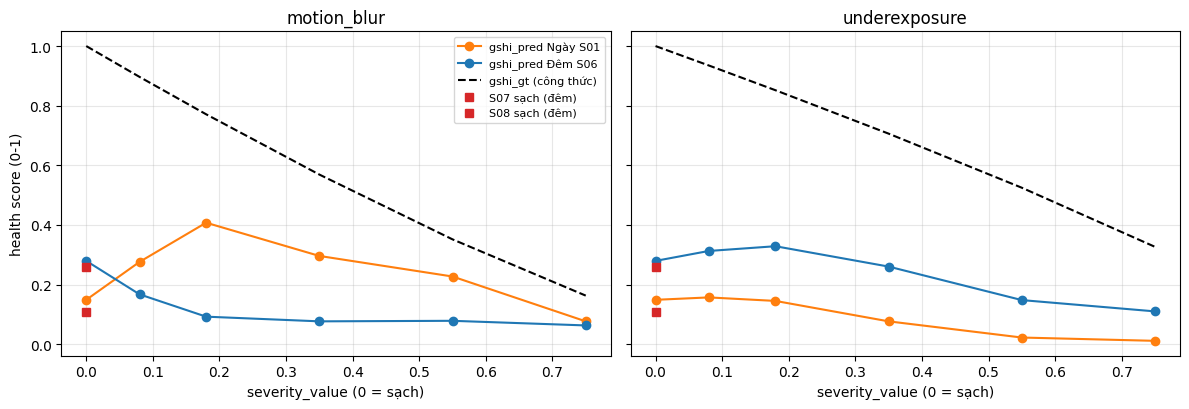

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
colors = {"day": "tab:orange", "night": "tab:blue"}
for ax, corr in zip(axes, ["motion_blur", "underexposure"]):
    for sid, lab in [("S01", "Ngày S01"), ("S06", "Đêm S06")]:
        d = res[(res.sample_id.str.startswith(sid)) & (res.corruption.isin(["clean", corr]))].sort_values("severity_value")
        ax.plot(d.severity_value, d.gshi_pred_f54, "o-", color=colors[d.time_of_day.iloc[0]], label=f"gshi_pred {lab}")
    d = res[(res.sample_id.str.startswith("S01")) & (res.corruption.isin(["clean", corr]))].sort_values("severity_value")
    ax.plot(d.severity_value, d.gshi_gt, "k--", label="gshi_gt (công thức)")
    for sid in ["S07", "S08"]:
        r = res[res.sample_id == f"{sid}_clean"].iloc[0]
        ax.plot([0], [r.gshi_pred_f54], "s", color="tab:red", label=f"{sid} sạch (đêm)")
    ax.set_title(corr); ax.set_xlabel("severity_value (0 = sạch)"); ax.grid(alpha=.3)
axes[0].set_ylabel("health score (0-1)")
axes[0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(WORK / "phn_curve.png", dpi=150)
plt.show()

## Bước 11 · Lưới 24 ảnh (frame 54) kèm `gshi_pred`

Để nhìn bằng mắt từng ảnh ứng với con số nào. Ảnh đêm sẽ tối; đó là đặc trưng tự nhiên của S06–S08, không phải lỗi hiển thị.

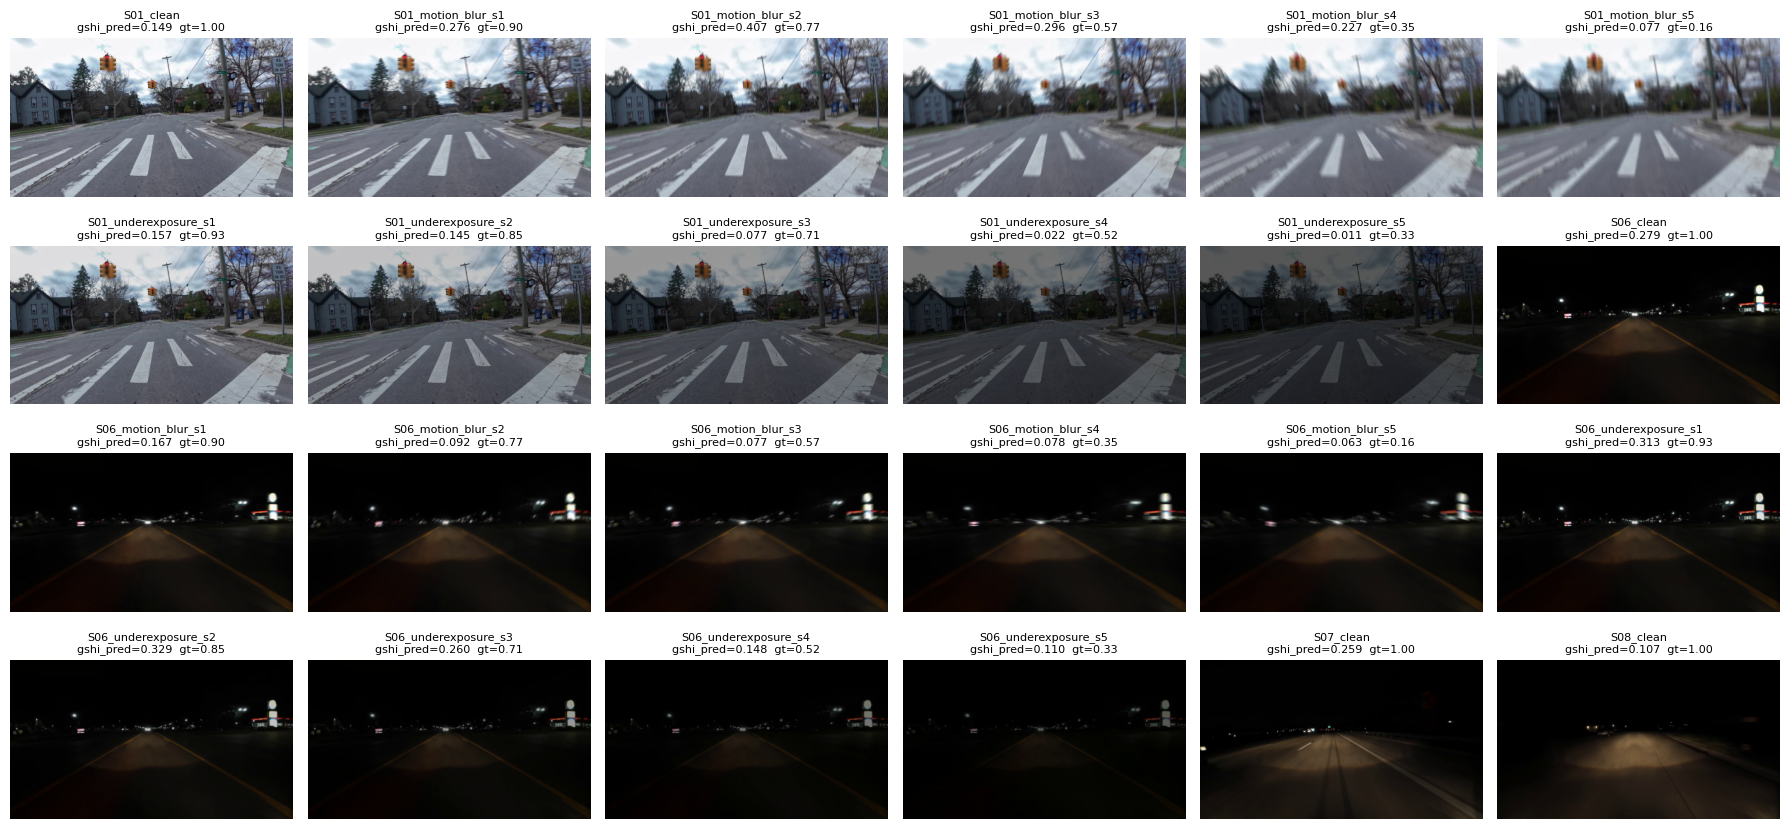

In [11]:
fig, axes = plt.subplots(4, 6, figsize=(18, 8.6))
for ax, c in zip(axes.ravel(), clips):
    j = c["idxs"].index(FRAME_IDX)
    ax.imshow(cv2.resize(c["frame_rgb"], (400, 225), interpolation=cv2.INTER_AREA))
    ax.set_title(f"{c['sample_id']}\ngshi_pred={c['health_frames'][j]:.3f}  gt={c['gshi_gt']:.2f}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(WORK / "phn_grid.png", dpi=130)
plt.show()

## Bước 12 · Lưu kết quả và cách đọc

**File ra** (trong `/kaggle/working`, tải về từ tab **Output** của notebook):
- `phn_24_results.csv`: bảng 24 ảnh ở Bước 9.
- `phn_per_frame.csv`: `gshi_pred` của từng frame (8 frame × 24 clip) để kiểm lại.
- `phn_curve.png`, `phn_grid.png`: hai hình ở Bước 10–11.
- `fetch_sha256.txt`: SHA-256 của 24 clip đã tải, dùng làm bằng chứng.

**Khi đưa vào báo cáo, tách ba loại câu:**
- **[NGUỒN]**: "Baseline của tác giả chấm S07 sạch = 0.181", "Pearson = 0.339 trên 610 clip".
- **[NHÓM ĐO]**: "Chạy lại trên frame 54 của S06 sạch cho `gshi_pred` = …", kèm `n = 24`, kèm kết quả Bước 8.
- **[GIẢ THUYẾT]**: giải thích vì sao ban đêm bị chấm thấp (ví dụ mô hình nhầm tối tự nhiên với vignetting) khi chưa có thí nghiệm kiểm chứng.

**Giới hạn cần ghi:**
- 24 ảnh, 1 frame mỗi clip, 2 cảnh có lỗi, nên chỉ nói về xu hướng.
- Mô hình được huấn luyện trên KITTI có lỗi tổng hợp, không phải DRIVE-C.
- `gshi_gt` là nhãn từ công thức, không phải độ tin cậy thực của detector.
- Frame 54 có thể khác trung bình 8 frame; so sánh xu hướng, đừng so từng giá trị tuyệt đối.